In [1]:
import pandas as pd
import seaborn as sns

In [2]:
nyka = pd.read_csv('Marketing Campaign/nykaa_campaign_data_with_nulls.csv')
purplle = pd.read_csv('Marketing Campaign/purplle_campaign_data_with_nulls.csv')
tira = pd.read_csv('Marketing Campaign/tira_campaign_data_with_nulls.csv')

In [3]:
nyka['Date'] = pd.to_datetime(nyka['Date'],dayfirst=True)
purplle['Date'] = pd.to_datetime(nyka['Date'],dayfirst=True)
tira['Date'] = pd.to_datetime(nyka['Date'],dayfirst=True)

In [4]:
prefix = "PU-CMP-"
modifed_id = prefix+(purplle.index+1000).astype(str)
purplle['Campaign_ID'] = purplle['Campaign_ID'].fillna(pd.Series(modifed_id,index=purplle.index))
print("Remaining nulls:", purplle['Campaign_ID'].isnull().sum())
print("Duplicates:", purplle['Campaign_ID'].duplicated().sum())

Remaining nulls: 0
Duplicates: 0


In [5]:
prefix1 = "TI-CMP-"
modifed_id2 = prefix1+(tira.index+1000).astype(str)
tira['Campaign_ID'] = tira['Campaign_ID'].fillna(pd.Series(modifed_id2,index=tira.index))
print("Remaining nulls:", tira['Campaign_ID'].isnull().sum())
print("Duplicates:", tira['Campaign_ID'].duplicated().sum())

Remaining nulls: 0
Duplicates: 0


In [6]:
nyka = nyka.dropna().reset_index(drop=True)
purplle = purplle.dropna().reset_index(drop=True)
tira = tira.dropna().reset_index(drop=True)

In [7]:
purplle

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,PU-CMP-1000,Paid Ads,Working Women,6.0,"Facebook, Google",31869.0,3490.0,1946.0,902.0,493394.0,55.93,8.78,Tamil,19.89,Premium Shoppers,2025-04-29
1,PU-CMP-1003,Paid Ads,Youth,15.0,"Instagram, WhatsApp",73258.0,5893.0,2565.0,1970.0,1341570.0,103.76,5.56,Bengali,14.23,College Students,2025-06-04
2,PU-CMP-1005,SEO,Tier 2 City Customers,12.0,Email,18715.0,976.0,555.0,364.0,158340.0,411.09,0.06,Bengali,10.13,College Students,2024-09-23
3,PU-CMP-1007,Paid Ads,College Students,12.0,"WhatsApp, Google",87117.0,5441.0,2231.0,1716.0,713856.0,42.22,8.85,Hindi,10.78,Tier 2 City Customers,2025-05-31
4,PU-CMP-1008,Paid Ads,Tier 2 City Customers,19.0,"Google, Email, Facebook",89807.0,4931.0,2639.0,2052.0,627912.0,124.35,1.46,Hindi,10.71,Tier 2 City Customers,2025-03-24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26109,PU-CMP-56548,Influencer,Youth,30.0,"Instagram, Google, WhatsApp",87864.0,11544.0,4785.0,1524.0,757428.0,46.79,9.62,Bengali,20.32,Working Women,2024-09-12
26110,PU-CMP-56549,Email,Working Women,30.0,"Facebook, Instagram",50865.0,6078.0,1933.0,922.0,200996.0,71.07,2.07,Bengali,17.56,Premium Shoppers,2025-05-11
26111,PU-CMP-56550,SEO,Premium Shoppers,10.0,"WhatsApp, Instagram",58191.0,7763.0,3471.0,2132.0,1097980.0,73.52,6.00,Tamil,22.97,Youth,2025-02-16
26112,PU-CMP-56551,Email,Tier 2 City Customers,12.0,"YouTube, Google",85085.0,8986.0,4096.0,2308.0,800876.0,53.17,5.53,Tamil,18.09,College Students,2024-11-18


In [7]:
MCPP = pd.concat([nyka,purplle,tira],ignore_index=True)

In [11]:
MCPP

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Profit_Loss,Language,Engagement_Score,Customer_Segment,Date,Profit_Loss_Label
0,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83,3.26,800860.69,Hindi,7.24,College Students,2025-04-06,Profit
1,NY-CMP-1004,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.60,0.80,230717.20,Hindi,7.29,Tier 2 City Customers,2024-12-29,Profit
2,NY-CMP-1008,Influencer,Premium Shoppers,27.0,"Facebook, WhatsApp, Email",73813.0,8680.0,5031.0,2551.0,1058665.0,87.74,3.73,834840.26,Hindi,22.03,Tier 2 City Customers,2025-03-24,Profit
3,NY-CMP-1011,SEO,Youth,7.0,"Facebook, YouTube",39696.0,5623.0,1136.0,661.0,286874.0,163.52,1.65,178787.28,Hindi,18.69,Premium Shoppers,2024-12-21,Profit
4,NY-CMP-1013,SEO,Youth,14.0,Email,96303.0,3749.0,1785.0,940.0,441800.0,282.05,0.67,176673.00,Tamil,6.72,Premium Shoppers,2024-10-29,Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78018,TI-CMP-56536,Paid Ads,Working Women,7.0,"WhatsApp, YouTube, Google",86601.0,9037.0,2655.0,2062.0,1620732.0,47.52,15.54,1522745.76,Bengali,15.88,Working Women,2024-11-09,Profit
78019,TI-CMP-56537,Influencer,Tier 2 City Customers,25.0,Email,41312.0,1723.0,751.0,599.0,247986.0,191.85,1.16,133067.85,Hindi,7.44,Tier 2 City Customers,2024-09-25,Profit
78020,TI-CMP-56540,Influencer,Premium Shoppers,17.0,"Google, Email, Instagram",37816.0,1374.0,526.0,270.0,212220.0,497.82,0.58,77808.60,Tamil,5.74,College Students,2025-05-30,Profit
78021,TI-CMP-56545,Social Media,College Students,7.0,"Facebook, Instagram, YouTube",78207.0,3086.0,883.0,620.0,199020.0,362.11,-0.11,-25488.20,English,5.87,College Students,2024-07-20,Loss


In [8]:
total_cost = MCPP['Acquisition_Cost'] * MCPP['Conversions']
profit_loss = round(MCPP['Revenue']-total_cost,2)
roi_index = MCPP.columns.get_loc('ROI')
MCPP.insert(roi_index+1,'Profit_Loss',profit_loss)
print(f"Profit_Loss column added at position {roi_index + 1}")
print(MCPP[['ROI', 'Profit_Loss']].head())

Profit_Loss column added at position 12
    ROI  Profit_Loss
0  3.26    800860.69
1  0.80    230717.20
2  3.73    834840.26
3  1.65    178787.28
4  0.67    176673.00


In [9]:
MCPP['Profit_Loss_Label'] = MCPP['Profit_Loss'].apply(
    lambda x: 'Profit' if x > 0 else 'Loss')

In [12]:
MCPP.to_csv('MCPP.csv',index=False)

In [9]:
nyka[['Duration','Impressions','Clicks','Leads','Conversions','Revenue','Acquisition_Cost','ROI','Engagement_Score']].corr()

,Duration,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Engagement_Score
Duration,1.000000,0.007509,0.000704,-0.001793,0.000480,0.004277,-0.005778,0.006176,-0.001791
Impressions,0.007509,1.000000,0.690839,0.615312,0.564460,0.497417,-0.432957,0.388002,-0.003833
Clicks,0.000704,0.690839,1.000000,0.890228,0.815713,0.717150,-0.478024,0.561376,0.625054
Leads,-0.001793,0.615312,0.890228,1.000000,0.916567,0.806829,-0.471373,0.631070,0.664984
Conversions,0.000480,0.564460,0.815713,0.916567,1.000000,0.881451,-0.461671,0.691271,0.640566
Revenue,0.004277,0.497417,0.717150,0.806829,0.881451,1.000000,-0.405983,0.784465,0.562781
Acquisition_Cost,-0.005778,-0.432957,-0.478024,-0.471373,-0.461671,-0.405983,1.000000,-0.372188,-0.423236
ROI,0.006176,0.388002,0.561376,0.631070,0.691271,0.784465,-0.372188,1.000000,0.443239
Engagement_Score,-0.001791,-0.003833,0.625054,0.664984,0.640566,0.562781,-0.423236,0.443239,1.000000


<Axes: >

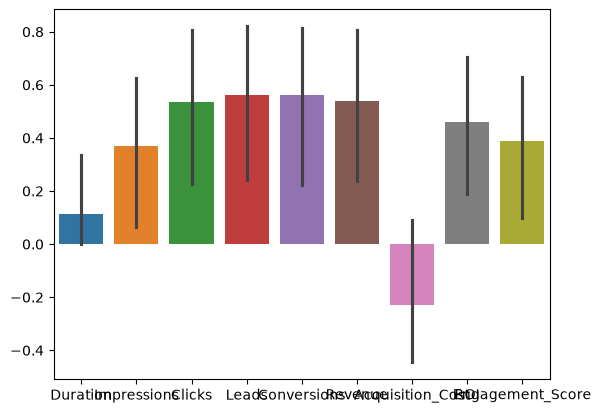

In [10]:
sns.barplot(nyka[['Duration','Impressions','Clicks','Leads','Conversions','Revenue','Acquisition_Cost','ROI','Engagement_Score']].corr())

In [57]:
MCPP

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Language,Engagement_Score,Customer_Segment,Date
0,NY-CMP-1000,Social Media,College Students,21.0,"WhatsApp, YouTube",57804.0,6156.0,3616.0,2355.0,1867515.0,78.86,6.14,Hindi,20.98,College Students,2025-04-29
1,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83,3.26,Hindi,7.24,College Students,2025-04-06
2,NY-CMP-1002,Influencer,Youth,23.0,"WhatsApp, Google, YouTube",15536.0,2182.0,952.0,755.0,197055.0,90.60,1.88,English,25.03,College Students,2025-01-14
3,NY-CMP-1003,Email,Working Women,18.0,"YouTube, Facebook, Instagram",88114.0,8413.0,2231.0,947.0,376906.0,249.07,0.60,Hindi,13.15,Not Listed,2025-06-04
4,NY-CMP-1004,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.60,0.80,Hindi,7.29,Tier 2 City Customers,2024-12-29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166660,TI-CMP-56550,Not Available,Tier 2 City Customers,11.0,"Instagram, YouTube, Email",55006.0,3799.0,1866.0,1099.0,454986.0,213.21,0.94,Bengali,10.70,Youth,2025-02-16
166661,TI-CMP-56551,SEO,Working Women,20.0,"Google, Instagram",54886.0,1578.0,634.0,1025.0,136514.0,436.24,-0.09,English,4.66,Working Women,2024-11-18
166662,TI-CMP-56552,Email,Unknown,13.0,"Facebook, Instagram",97954.0,11480.0,4567.0,2144.0,445952.0,78.77,1.64,Unknown,18.57,Premium Shoppers,2024-10-24
166663,TI-CMP-56553,Influencer,Premium Shoppers,22.0,"Google, Email",11669.0,4681.0,122.0,44.0,26884.0,4199.93,-0.76,English,5.35,Working Women,2025-05-22


In [66]:
total_cost = MCPP['Acquisition_Cost'] * MCPP['Conversions']
profit_loss = round(MCPP['Revenue']-total_cost,2)
roi_index = MCPP.columns.get_loc('ROI')
MCPP.insert(roi_index+1,'Profit_Loss',profit_loss)
print(f"{name}: Profit_Loss column added at position {roi_index + 1}")
print(MCPP[['ROI', 'Profit_Loss']].head())

tira: Profit_Loss column added at position 12
    ROI  Profit_Loss
0  6.14   1681799.70
1  3.26    800860.69
2  1.88    128652.00
3  0.60    141036.71
4  0.80    230717.20


In [67]:
MCPP['Profit_Loss'].isna().sum()

np.int64(0)

In [69]:
MCPP['Profit_Loss_Label'] = MCPP['Profit_Loss'].apply(
    lambda x: 'Profit' if x > 0 else ('Loss' if x < 0 else 'Break-even'))

In [11]:
MCPP

,Campaign_ID,Campaign_Type,Target_Audience,Duration,Channel_Used,Impressions,Clicks,Leads,Conversions,Revenue,Acquisition_Cost,ROI,Profit_Loss,Language,Engagement_Score,Customer_Segment,Date,Profit_Loss_Label
0,NY-CMP-1001,Paid Ads,Tier 2 City Customers,18.0,YouTube,91801.0,3321.0,1971.0,1357.0,1046247.0,180.83,3.26,800860.69,Hindi,7.24,College Students,2025-04-06,Profit
1,NY-CMP-1004,Paid Ads,College Students,10.0,"Facebook, Instagram",96871.0,3743.0,2060.0,1258.0,518296.0,228.60,0.80,230717.20,Hindi,7.29,Tier 2 City Customers,2024-12-29,Profit
2,NY-CMP-1008,Influencer,Premium Shoppers,27.0,"Facebook, WhatsApp, Email",73813.0,8680.0,5031.0,2551.0,1058665.0,87.74,3.73,834840.26,Hindi,22.03,Tier 2 City Customers,2025-03-24,Profit
3,NY-CMP-1011,SEO,Youth,7.0,"Facebook, YouTube",39696.0,5623.0,1136.0,661.0,286874.0,163.52,1.65,178787.28,Hindi,18.69,Premium Shoppers,2024-12-21,Profit
4,NY-CMP-1013,SEO,Youth,14.0,Email,96303.0,3749.0,1785.0,940.0,441800.0,282.05,0.67,176673.00,Tamil,6.72,Premium Shoppers,2024-10-29,Profit
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
78018,TI-CMP-56536,Paid Ads,Working Women,7.0,"WhatsApp, YouTube, Google",86601.0,9037.0,2655.0,2062.0,1620732.0,47.52,15.54,1522745.76,Bengali,15.88,Working Women,2024-11-09,Profit
78019,TI-CMP-56537,Influencer,Tier 2 City Customers,25.0,Email,41312.0,1723.0,751.0,599.0,247986.0,191.85,1.16,133067.85,Hindi,7.44,Tier 2 City Customers,2024-09-25,Profit
78020,TI-CMP-56540,Influencer,Premium Shoppers,17.0,"Google, Email, Instagram",37816.0,1374.0,526.0,270.0,212220.0,497.82,0.58,77808.60,Tamil,5.74,College Students,2025-05-30,Profit
78021,TI-CMP-56545,Social Media,College Students,7.0,"Facebook, Instagram, YouTube",78207.0,3086.0,883.0,620.0,199020.0,362.11,-0.11,-25488.20,English,5.87,College Students,2024-07-20,Loss


In [78]:
MCPP.to_csv('MCPP.csv',index=False)

### EDA for Understanding

In [12]:
import matplotlib.pyplot as plt

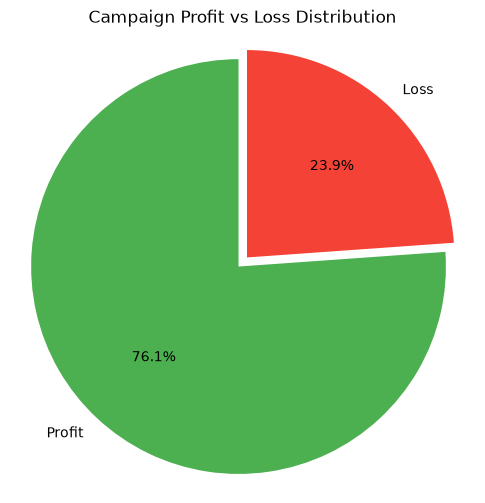

In [18]:
counts = MCPP['Profit_Loss_Label'].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    counts,
    labels=counts.index,
    autopct='%1.1f%%',
    colors=['#4CAF50', '#F44336'],   # green for Profit, red for Loss
    startangle=90,
    explode=[0.03] * len(counts))
plt.title('Campaign Profit vs Loss Distribution')
plt.axis('equal')
plt.show()

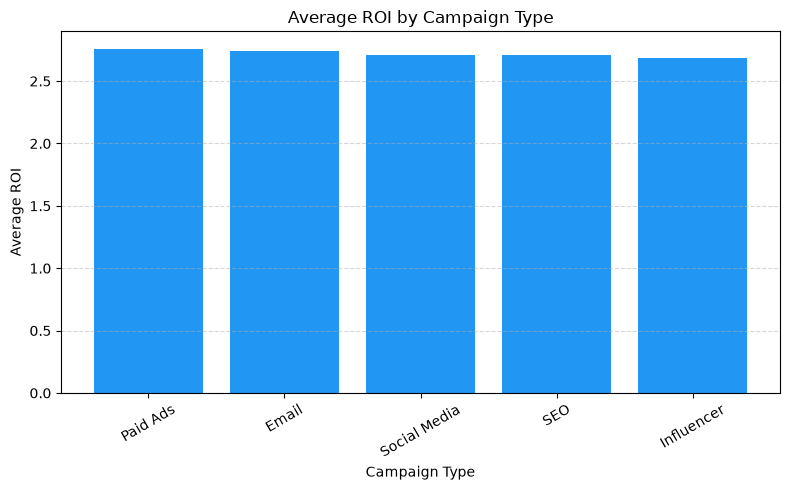

In [19]:
avg_roi = MCPP.groupby('Campaign_Type')['ROI'].mean().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(avg_roi.index, avg_roi.values, color='#2196F3')
plt.title('Average ROI by Campaign Type')
plt.xlabel('Campaign Type')
plt.ylabel('Average ROI')
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

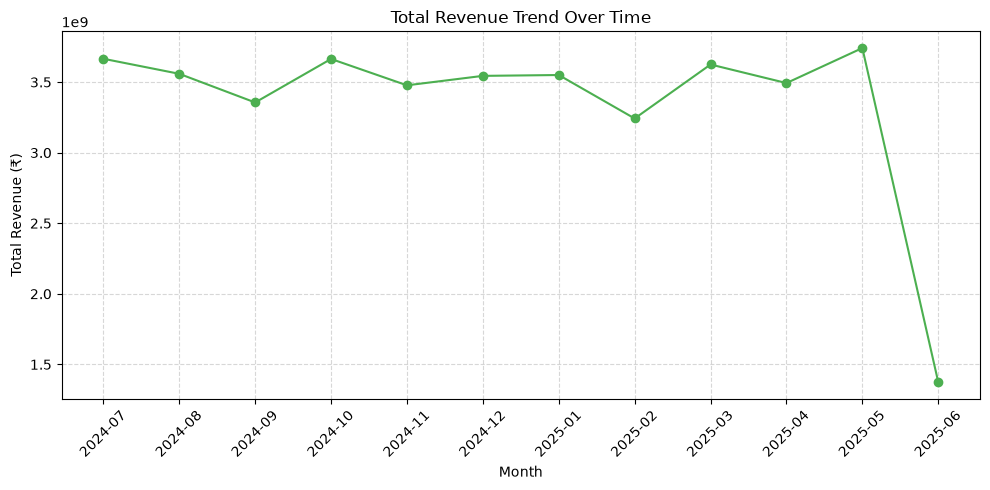

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

MCPP['Date'] = pd.to_datetime(MCPP['Date'], format='%d-%m-%Y')
monthly_revenue = MCPP.groupby(MCPP['Date'].dt.to_period('M'))['Revenue'].sum()

plt.figure(figsize=(10, 5))
plt.plot(monthly_revenue.index.astype(str), monthly_revenue.values, marker='o', color='#4CAF50')
plt.title('Total Revenue Trend Over Time')
plt.xlabel('Month')
plt.ylabel('Total Revenue (\u20b9)')
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

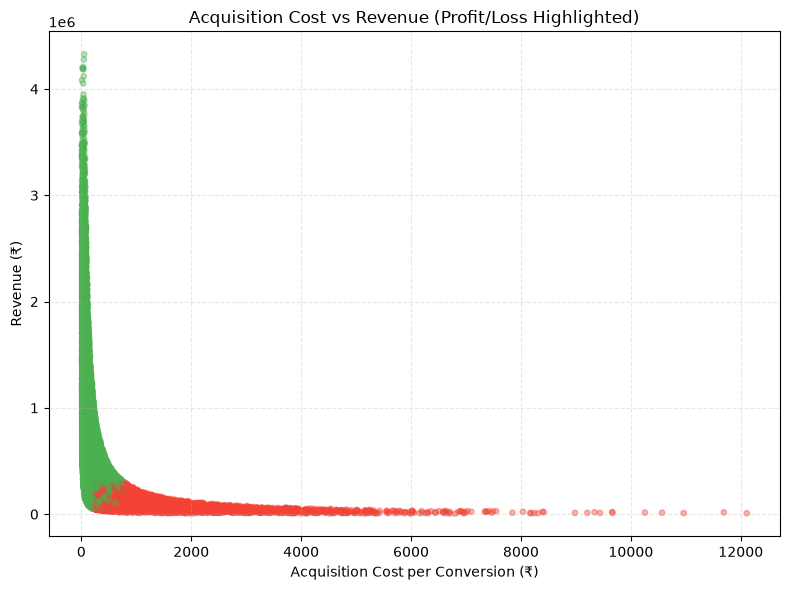

In [24]:
colors = MCPP['Profit_Loss_Label'].map({'Profit': '#4CAF50', 'Loss': '#F44336'})

plt.figure(figsize=(8, 6))
plt.scatter(MCPP['Acquisition_Cost'], MCPP['Revenue'], c=colors, alpha=0.4, s=15)
plt.title('Acquisition Cost vs Revenue (Profit/Loss Highlighted)')
plt.xlabel('Acquisition Cost per Conversion (\u20b9)')
plt.ylabel('Revenue (\u20b9)')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()